### Importing libraries

In [ ]:

import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

### Loading dataset 

In [ ]:
df = pd.read_csv(r"C:\Users\anarrasulzada\Downloads\archive (7)\vgsales.csv")

print(df.head())
print(df.shape)

   Rank                      Name Platform    Year         Genre Publisher  \
0     1                Wii Sports      Wii  2006.0        Sports  Nintendo   
1     2         Super Mario Bros.      NES  1985.0      Platform  Nintendo   
2     3            Mario Kart Wii      Wii  2008.0        Racing  Nintendo   
3     4         Wii Sports Resort      Wii  2009.0        Sports  Nintendo   
4     5  Pokemon Red/Pokemon Blue       GB  1996.0  Role-Playing  Nintendo   

   NA_Sales  EU_Sales  JP_Sales  Other_Sales  Global_Sales  
0     41.49     29.02      3.77         8.46         82.74  
1     29.08      3.58      6.81         0.77         40.24  
2     15.85     12.88      3.79         3.31         35.82  
3     15.75     11.01      3.28         2.96         33.00  
4     11.27      8.89     10.22         1.00         31.37  
(16598, 11)


### Checking missing values

In [ ]:
print(df.isnull().sum())

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64


### Checking duplicate rows

In [ ]:
print(df.duplicated().sum())

0


### Cleaning missing value  

In [ ]:
df = df.dropna(subset=["Year"])
df["Publisher"] = df["Publisher"].fillna("Unknown")
print(df.isnull().sum())

Rank            0
Name            0
Platform        0
Year            0
Genre           0
Publisher       0
NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
Global_Sales    0
dtype: int64


### Fixing the year column

In [40]:
df["Year"] = df["Year"].astype(int)

print(df["Year"].dtype)
print(df.shape)


int64
(16327, 11)


### Dataset structure

In [ ]:
print(df.info())

<class 'pandas.DataFrame'>
Index: 16327 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16327 non-null  int64  
 1   Name          16327 non-null  str    
 2   Platform      16327 non-null  str    
 3   Year          16327 non-null  int64  
 4   Genre         16327 non-null  str    
 5   Publisher     16327 non-null  str    
 6   NA_Sales      16327 non-null  float64
 7   EU_Sales      16327 non-null  float64
 8   JP_Sales      16327 non-null  float64
 9   Other_Sales   16327 non-null  float64
 10  Global_Sales  16327 non-null  float64
dtypes: float64(5), int64(2), str(4)
memory usage: 1.5 MB
None


### Main numeric columns

In [ ]:
print(df[["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales", "Global_Sales"]].describe())

           NA_Sales      EU_Sales      JP_Sales   Other_Sales  Global_Sales
count  16327.000000  16327.000000  16327.000000  16327.000000  16327.000000
mean       0.265415      0.147554      0.078661      0.048325      0.540232
std        0.821591      0.508766      0.311557      0.189885      1.565732
min        0.000000      0.000000      0.000000      0.000000      0.010000
25%        0.000000      0.000000      0.000000      0.000000      0.060000
50%        0.080000      0.020000      0.000000      0.010000      0.170000
75%        0.240000      0.110000      0.040000      0.040000      0.480000
max       41.490000     29.020000     10.220000     10.570000     82.740000


### Checking the year range

In [ ]:
print(df["Year"].min())
print(df["Year"].max())

1980
2020


### Global sales by genre

In [44]:
genre_sales = (
    df.groupby("Genre")["Global_Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(genre_sales)


Genre
Action          1722.88
Sports          1309.24
Shooter         1026.20
Role-Playing     923.84
Platform         829.15
Misc             797.62
Racing           726.77
Fighting         444.05
Simulation       390.16
Puzzle           242.22
Adventure        234.80
Strategy         173.43
Name: Global_Sales, dtype: float64


### Checking the top genres

In [ ]:
print(genre_sales.head())

Genre
Action          1722.88
Sports          1309.24
Shooter         1026.20
Role-Playing     923.84
Platform         829.15
Name: Global_Sales, dtype: float64


### Global sales by platform

In [ ]:
platform_sales = (
    df.groupby("Platform")["Global_Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(platform_sales)

Platform
PS2     1233.46
X360     969.61
PS3      949.35
Wii      909.81
DS       818.96
PS       727.39
GBA      313.56
PSP      291.71
PS4      278.10
PC       255.05
Name: Global_Sales, dtype: float64


### Global sales by publisher

In [47]:
publisher_sales = (
    df.groupby("Publisher")["Global_Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(publisher_sales)


Publisher
Nintendo                        1784.43
Electronic Arts                 1093.39
Activision                       721.41
Sony Computer Entertainment      607.28
Ubisoft                          473.54
Take-Two Interactive             399.30
THQ                              340.44
Konami Digital Entertainment     278.56
Sega                             270.70
Namco Bandai Games               253.65
Name: Global_Sales, dtype: float64


### Regional sales share by genre

In [ ]:
genre_region_sales = (
    df.groupby("Genre")[["NA_Sales", "EU_Sales", "JP_Sales", "Global_Sales"]]
    .sum()
)

genre_region_sales["NA_Share"] = (
    genre_region_sales["NA_Sales"] / genre_region_sales["Global_Sales"] * 100
)

genre_region_sales["EU_Share"] = (
    genre_region_sales["EU_Sales"] / genre_region_sales["Global_Sales"] * 100
)

genre_region_sales["JP_Share"] = (
    genre_region_sales["JP_Sales"] / genre_region_sales["Global_Sales"] * 100
)

print(
    genre_region_sales[
        ["NA_Share", "EU_Share", "JP_Share"]
    ].round(2)
)

              NA_Share  EU_Share  JP_Share
Genre                                     
Action           50.02     29.98      9.21
Adventure        43.47     27.17     22.15
Fighting         49.71     22.52     19.63
Misc             50.46     26.81     13.37
Platform         53.79     24.20     15.76
Puzzle           50.37     20.86     23.40
Racing           49.11     32.52      7.79
Role-Playing     35.34     20.30     37.92
Shooter          56.05     30.25      3.72
Simulation       46.59     29.01     16.29
Sports           51.18     28.36     10.29
Strategy         39.15     25.91     28.31


### Overall regional market share

In [ ]:
regional_share = (
    df[["NA_Sales", "EU_Sales", "JP_Sales"]].sum()
    / df["Global_Sales"].sum()
    * 100
)

print(regional_share.round(2))

NA_Sales    49.13
EU_Sales    27.31
JP_Sales    14.56
dtype: float64


### Finding the leading genre in each region

In [ ]:
regional_genre_sales = (
    df.groupby("Genre")[["NA_Sales", "EU_Sales", "JP_Sales"]]
    .sum()
)

leaders = []

for region in ["NA_Sales", "EU_Sales", "JP_Sales"]:
    top_genre = regional_genre_sales[region].idxmax()
    top_sales = regional_genre_sales.loc[top_genre, region]
    region_total = regional_genre_sales[region].sum()
    share = top_sales / region_total * 100

    leaders.append([region, top_genre, top_sales, share])

regional_leaders = pd.DataFrame(
    leaders,
    columns=["Region", "Top_Genre", "Sales", "Region_Share"]
)

regional_leaders["Region_Share"] = regional_leaders["Region_Share"].round(2)

print(regional_leaders)

     Region     Top_Genre   Sales  Region_Share
0  NA_Sales        Action  861.80         19.89
1  EU_Sales        Action  516.48         21.44
2  JP_Sales  Role-Playing  350.29         27.27


### Comparing genre preference gaps

In [ ]:
genre_preferences = genre_region_sales[
    ["NA_Share", "EU_Share", "JP_Share"]
].copy()

genre_preferences["Preference_Gap"] = (
    genre_preferences.max(axis=1) - genre_preferences.min(axis=1)
)

print(
    genre_preferences
    .sort_values("Preference_Gap", ascending=False)
    .round(2)
)

              NA_Share  EU_Share  JP_Share  Preference_Gap
Genre                                                     
Shooter          56.05     30.25      3.72           52.33
Racing           49.11     32.52      7.79           41.32
Sports           51.18     28.36     10.29           40.89
Action           50.02     29.98      9.21           40.81
Platform         53.79     24.20     15.76           38.03
Misc             50.46     26.81     13.37           37.09
Simulation       46.59     29.01     16.29           30.31
Fighting         49.71     22.52     19.63           30.08
Puzzle           50.37     20.86     23.40           29.51
Adventure        43.47     27.17     22.15           21.32
Role-Playing     35.34     20.30     37.92           17.61
Strategy         39.15     25.91     28.31           13.23


### Top 10 best-selling games

In [ ]:
top_games = (
    df[["Name", "Platform", "Genre", "Global_Sales"]]
    .sort_values("Global_Sales", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

print(top_games)

                        Name Platform         Genre  Global_Sales
0                 Wii Sports      Wii        Sports         82.74
1          Super Mario Bros.      NES      Platform         40.24
2             Mario Kart Wii      Wii        Racing         35.82
3          Wii Sports Resort      Wii        Sports         33.00
4   Pokemon Red/Pokemon Blue       GB  Role-Playing         31.37
5                     Tetris       GB        Puzzle         30.26
6      New Super Mario Bros.       DS      Platform         30.01
7                   Wii Play      Wii          Misc         29.02
8  New Super Mario Bros. Wii      Wii      Platform         28.62
9                  Duck Hunt      NES       Shooter         28.31


### Comparing average sales by decade

In [ ]:
# grouping release years into broader market eras
df["Decade"] = (df["Year"] // 10) * 10

decade_sales = (
    df[df["Decade"].isin([1980, 1990, 2000, 2010])]
    .groupby("Decade")["Global_Sales"]
    .agg(["mean", "sum", "count"])
    .round(2)
)

decade_sales = decade_sales.rename(
    columns={
        "mean": "Avg_Sales_Per_Game",
        "sum": "Total_Sales",
        "count": "Game_Count"
    }
)

print(decade_sales)

        Avg_Sales_Per_Game  Total_Sales  Game_Count
Decade                                             
1980                  1.84       376.58         205
1990                  0.72      1278.91        1769
2000                  0.50      4644.02        9208
2010                  0.49      2520.56        5144


### Identifying the strongest decade

In [ ]:
best_decade = decade_sales["Avg_Sales_Per_Game"].idxmax()
best_decade_avg = decade_sales.loc[best_decade, "Avg_Sales_Per_Game"]

print(best_decade)
print(best_decade_avg)

1980
1.84


### Yearly global sales

In [ ]:
yearly_sales = (
    df[df["Year"].between(1980, 2016)]
    .groupby("Year")["Global_Sales"]
    .sum()
    .reset_index()
)

print(yearly_sales.head())
print(yearly_sales.tail())

   Year  Global_Sales
0  1980         11.38
1  1981         35.77
2  1982         28.86
3  1983         16.79
4  1984         50.36
    Year  Global_Sales
32  2012        363.54
33  2013        368.11
34  2014        337.05
35  2015        264.44
36  2016         70.93


### The peak sales year

In [ ]:
peak_year = yearly_sales.loc[yearly_sales["Global_Sales"].idxmax()]

print(peak_year)

Year            2008.0
Global_Sales     678.9
Name: 28, dtype: float64


### Top genres for regional comparison

In [ ]:
top_5_genres = genre_sales.head(5).index

top_genre_regions = (
    regional_genre_sales
    .loc[top_5_genres]
    .reset_index()
)

print(top_genre_regions)


          Genre  NA_Sales  EU_Sales  JP_Sales
0        Action    861.80    516.48    158.66
1        Sports    670.09    371.34    134.76
2       Shooter    575.16    310.45     38.18
3  Role-Playing    326.50    187.58    350.29
4      Platform    445.99    200.67    130.65


### Visualizing regional sales by genre

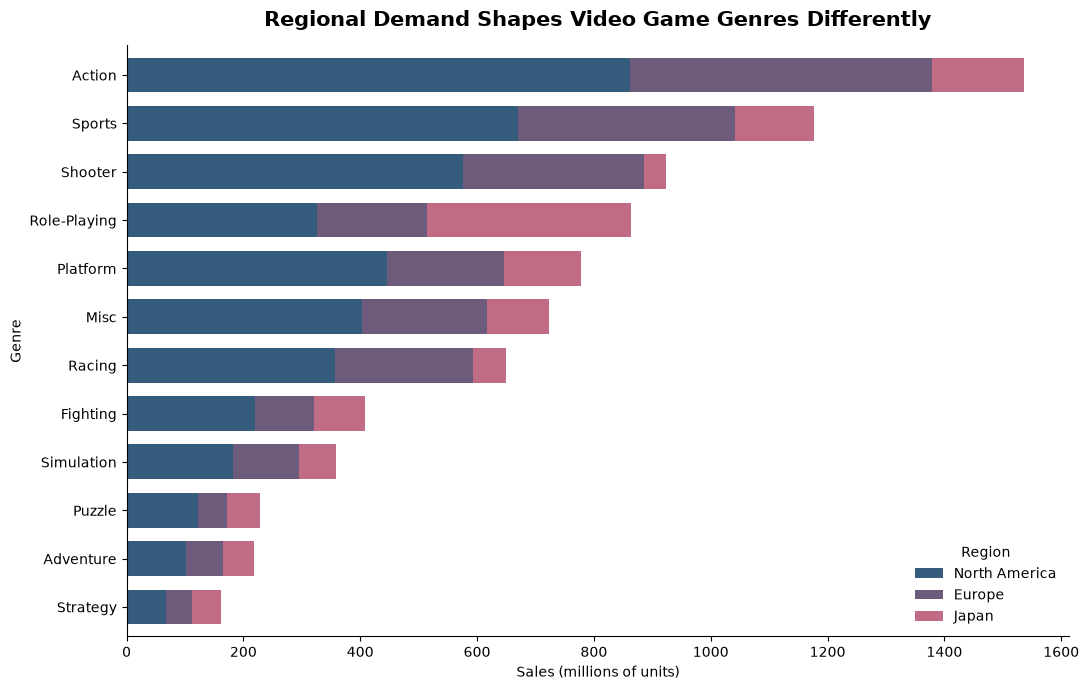

In [ ]:

# sorting genres by combined sales across the three main regions
genre_plot = regional_genre_sales.copy()
genre_plot["Regional_Total"] = genre_plot.sum(axis=1)

genre_plot = genre_plot.sort_values(
    "Regional_Total",
    ascending=True
)

ax = genre_plot[
    ["NA_Sales", "EU_Sales", "JP_Sales"]
].plot(
    kind="barh",
    stacked=True,
    figsize=(11, 7),
    width=0.72,
    color=["#355C7D", "#6C5B7B", "#C06C84"]
)

ax.set_title(
    "Regional Demand Shapes Video Game Genres Differently",
    fontsize=15,
    fontweight="bold",
    pad=14
)

ax.set_xlabel("Sales (millions of units)")
ax.set_ylabel("Genre")

ax.legend(
    ["North America", "Europe", "Japan"],
    title="Region",
    frameon=False
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### Yearly global sales trend

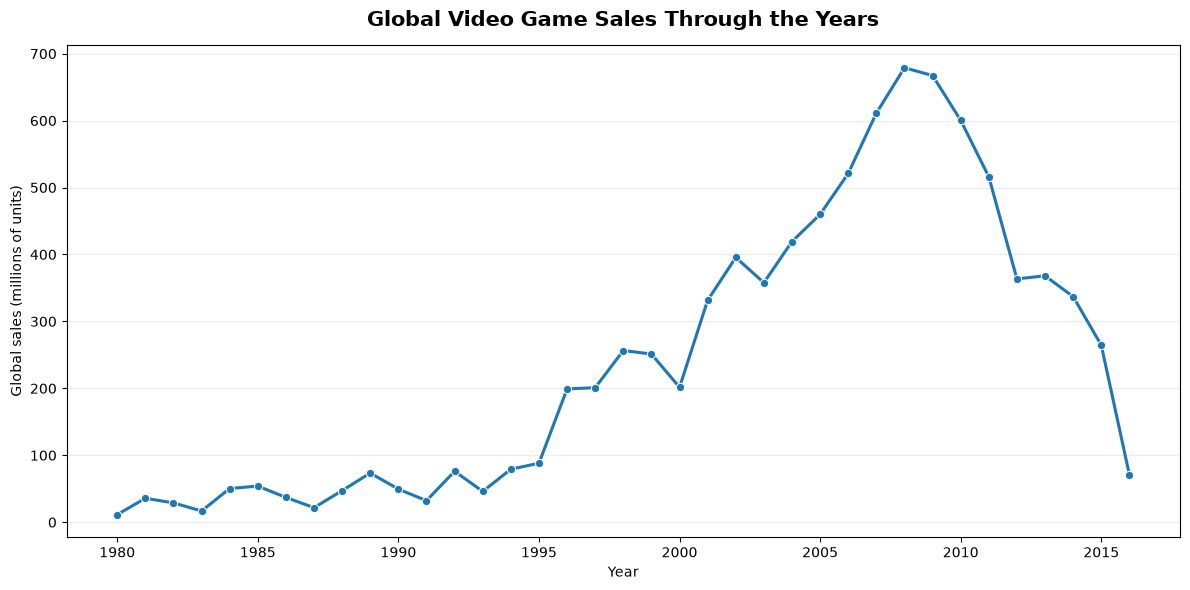

In [ ]:

# how total market sales changed over time
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=yearly_sales,
    x="Year",
    y="Global_Sales",
    marker="o",
    linewidth=2.2
)

plt.title(
    "Global Video Game Sales Through the Years",
    fontsize=15,
    fontweight="bold",
    pad=14
)

plt.xlabel("Year")
plt.ylabel("Global sales (millions of units)")

plt.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

### Visualizing the top publishers

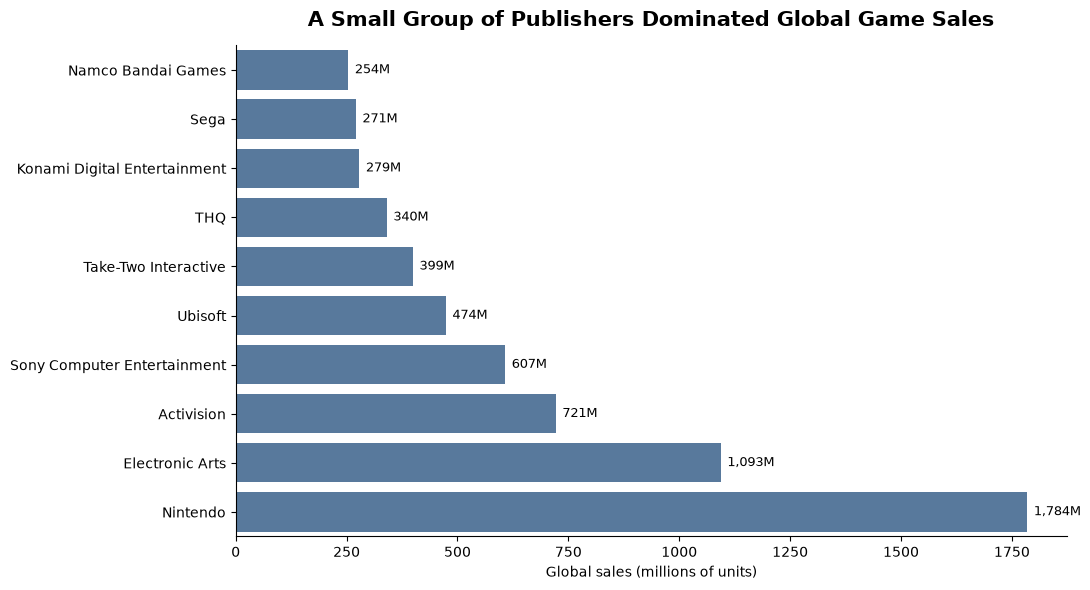

In [ ]:

# showing the publishers that generated the most global sales
publisher_plot = publisher_sales.sort_values()

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    x=publisher_plot.values,
    y=publisher_plot.index,
    color="#4C78A8"
)

for i, value in enumerate(publisher_plot.values):
    ax.text(
        value + 15,
        i,
        f"{value:,.0f}M",
        va="center",
        fontsize=9
    )

plt.title(
    "A Small Group of Publishers Dominated Global Game Sales",
    fontsize=15,
    fontweight="bold",
    pad=14
)

plt.xlabel("Global sales (millions of units)")
plt.ylabel("")

sns.despine()
plt.tight_layout()
plt.show()

### Comparing top genres across regions

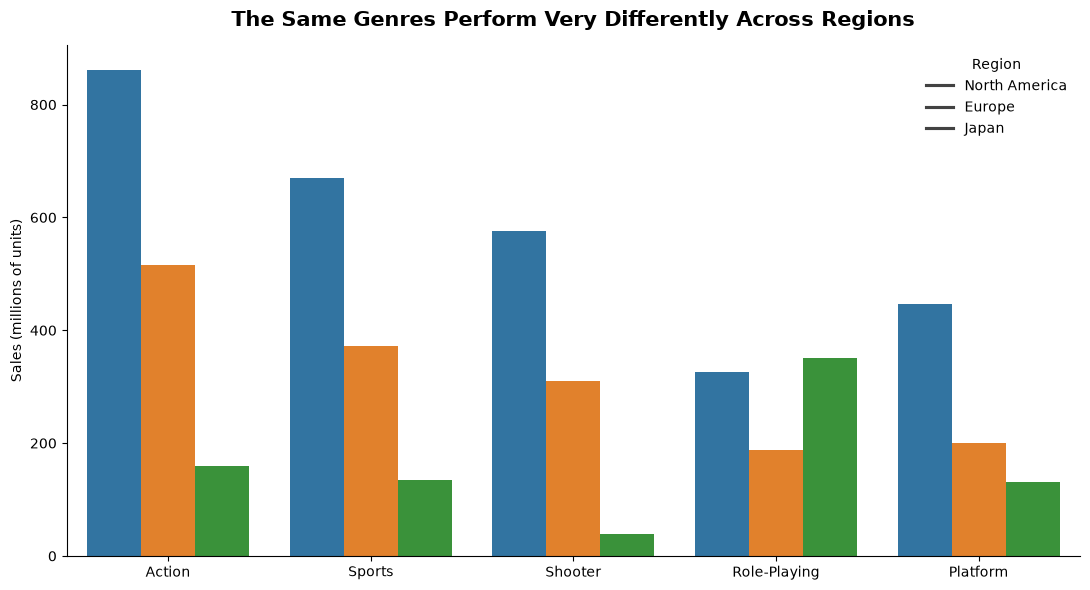

In [ ]:

genre_compare = top_genre_regions.melt(
    id_vars="Genre",
    value_vars=["NA_Sales", "EU_Sales", "JP_Sales"],
    var_name="Region",
    value_name="Sales"
)

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=genre_compare,
    x="Genre",
    y="Sales",
    hue="Region"
)

plt.title(
    "The Same Genres Perform Very Differently Across Regions",
    fontsize=15,
    fontweight="bold",
    pad=14
)

plt.xlabel("")
plt.ylabel("Sales (millions of units)")

ax.legend(
    title="Region",
    labels=["North America", "Europe", "Japan"],
    frameon=False
)

sns.despine()
plt.tight_layout()
plt.show()

### Regional preference gaps

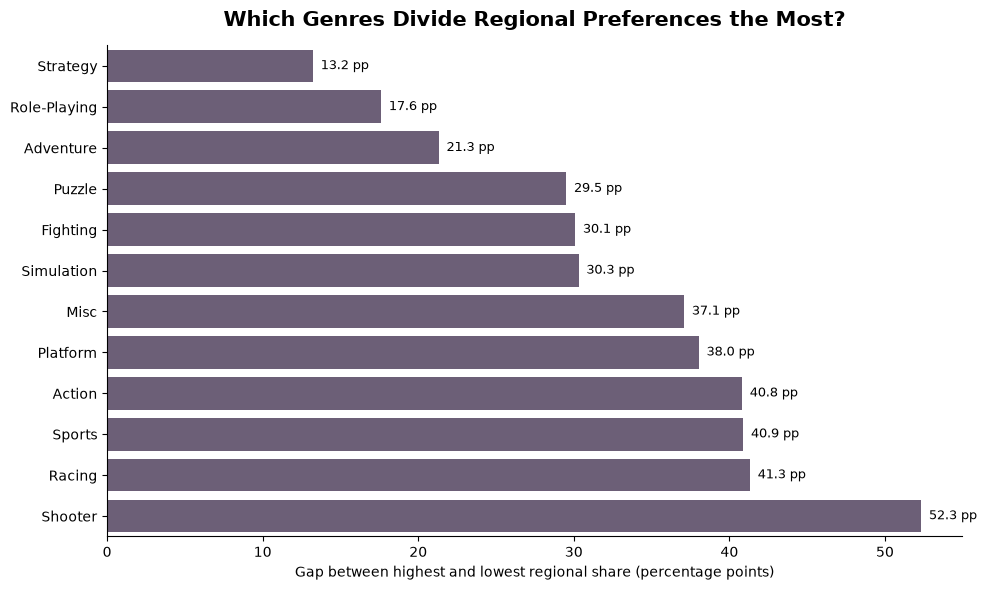

In [ ]:

# ranking genres by the difference between their strongest and weakest regional share
preference_plot = (
    genre_preferences
    .sort_values("Preference_Gap", ascending=True)
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=preference_plot.reset_index(),
    x="Preference_Gap",
    y="Genre",
    color="#6C5B7B"
)

for i, value in enumerate(preference_plot["Preference_Gap"]):
    ax.text(
        value + 0.5,
        i,
        f"{value:.1f} pp",
        va="center",
        fontsize=9
    )

plt.title(
    "Which Genres Divide Regional Preferences the Most?",
    fontsize=15,
    fontweight="bold",
    pad=14
)

plt.xlabel("Gap between highest and lowest regional share (percentage points)")
plt.ylabel("")

sns.despine()
plt.tight_layout()
plt.show()

### The global market split

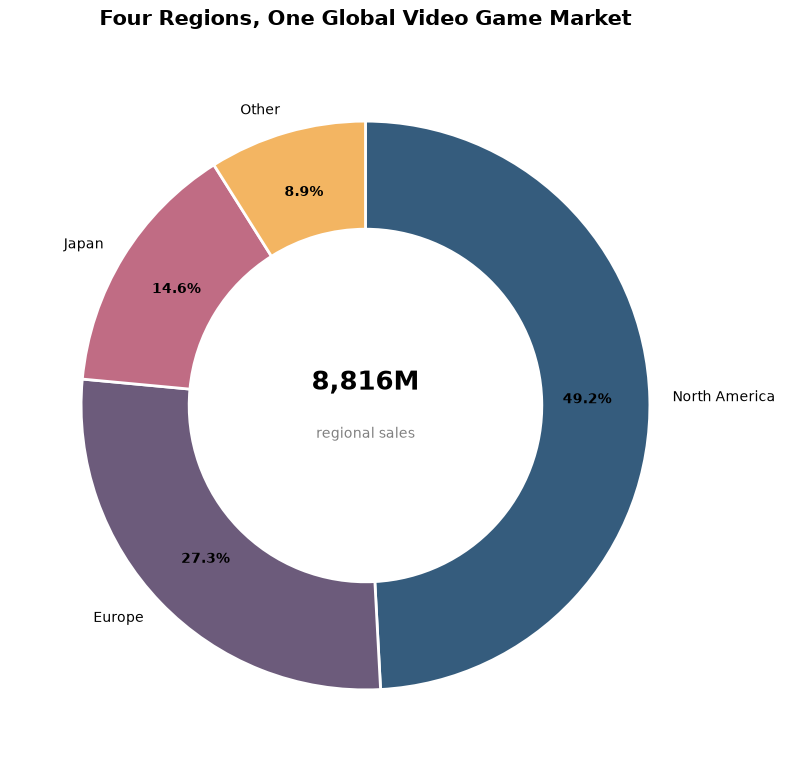

In [63]:

# showing how global sales are distributed across regions
market_split = df[
    ["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]
].sum()

labels = ["North America", "Europe", "Japan", "Other"]
colors = ["#355C7D", "#6C5B7B", "#C06C84", "#F3B562"]

fig, ax = plt.subplots(figsize=(8, 8))

wedges, texts, autotexts = ax.pie(
    market_split,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False,
    colors=colors,
    pctdistance=0.78,
    labeldistance=1.08,
    wedgeprops={
        "width": 0.38,
        "edgecolor": "white",
        "linewidth": 2
    }
)

for text in autotexts:
    text.set_fontsize(10)
    text.set_fontweight("bold")

total_sales = market_split.sum()

ax.text(
    0,
    0.08,
    f"{total_sales:,.0f}M",
    ha="center",
    va="center",
    fontsize=19,
    fontweight="bold"
)

ax.text(
    0,
    -0.10,
    "regional sales",
    ha="center",
    va="center",
    fontsize=10,
    color="gray"
)

plt.title(
    "Four Regions, One Global Video Game Market",
    fontsize=15,
    fontweight="bold",
    pad=18
)

plt.tight_layout()
plt.show()